In [1]:
import numpy as np
import cv2
import os
from PIL import Image, ImageDraw
from skimage.feature import graycomatrix, graycoprops, hog
from skimage.color import rgb2gray
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.utils import shuffle
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# _________________________________________________ Test Stage _____________________________________________
# _________________________________________Load Feature Extraction Vectores ________________________________
# ____________________________________ hog or glcm or orb , vgg , yolo , resnet ____________________________


In [41]:
# load Feature Extraction Vectors (hog, glcm, orb, vgg, yolo, resnet, ML, DL, ALL)
import numpy as np

# Set feature_type to one of: 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'resnet'
feature_type = 'all'  # Change to 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'resnet' as needed

# Load all arrays for shape info and switching
hog_features_array = np.load('Bin_Features/hog_features_array.npy')
glcm_features_array = np.load('Bin_Features/glcm_features_array.npy')
orb_features_array = np.load('Bin_Features/orb_features_array.npy')
vgg_features_array = np.load('Bin_Features/vgg_features_array.npy')
yolo_features_array = np.load('Bin_Features/yolo_features_array.npy')
resnet_features_array = np.load('Bin_Features/resnet_features_array.npy')
combined_ML_features = np.load('Bin_Features/combined_ML_features_array.npy')
combined_DL_features = np.load('Bin_Features/combined_DL_features_array.npy')
combined_all_features = np.load('Bin_Features/combined_all_features_array.npy')
labels_array = np.load('Bin_Features/labels_array_all_algorithms.npy')

features_array = None

if feature_type == 'all':
    features_array = combined_all_features
    print("Loaded ALL features (ML + DL).")
elif feature_type == 'ml':
    features_array = combined_ML_features
    print("Loaded ML features.")
elif feature_type == 'dl':
    features_array = combined_DL_features
    print("Loaded DL features.")
elif feature_type == 'hog':
    features_array = hog_features_array
    print("Loaded HOG features.")
elif feature_type == 'glcm':
    features_array = glcm_features_array
    print("Loaded GLCM features.")
elif feature_type == 'orb':
    features_array = orb_features_array
    print("Loaded ORB features.")
elif feature_type == 'vgg':
    features_array = vgg_features_array
    print("Loaded VGG features.")
elif feature_type == 'resnet':
    features_array = resnet_features_array
    print("Loaded ResNet features.")
elif feature_type == 'yolo':
    features_array = yolo_features_array
    print("Loaded YOLO features.")
else:
    raise ValueError("Invalid feature_type. Choose from 'all', 'ml', 'dl', 'hog', 'glcm', 'orb', 'vgg', 'yolo', 'resnet'.")

print('Features shape:', features_array.shape)
print('Labels shape:', labels_array.shape)

print(f"------++++++++ Load Feature Extraction Vectors is Done :- {feature_type} +++++++++-------------")

Loaded ALL features (ML + DL).
Features shape: (744, 4384)
Labels shape: (744,)
------++++++++ Load Feature Extraction Vectors is Done :- all +++++++++-------------


In [45]:
from sklearn.calibration import LabelEncoder
from data_processing import (
    remove_rows_per_class,
    oversample_to_original_counts,
    custom_oversample_to_target,
    process_data_for_accuracy
)

print("METHOD Random Oversampling to Original Counts")
X_processed1, y_processed1 = process_data_for_accuracy(
        features_array, labels_array,
        removal_ratio=0.6,
        oversampling_method='random',
        random_state=42
    )
    

print("\n" + "="*60)
print("TRAIN-TEST SPLIT")
print("="*60)
    
    # Choose which processed dataset to use (X_processed1, X_processed2, or X_processed3)
features, labels = X_processed1, y_processed1  # Using method 1 as example

# Encode string labels to integers if needed
if labels.dtype.type is np.str_ or labels.dtype.type is np.object_:
    le = LabelEncoder()
    labels = le.fit_transform(labels)


METHOD Random Oversampling to Original Counts

TRAIN-TEST SPLIT



Evaluating RandomForest...

Evaluating ExtraTrees...

Evaluating AdaBoost...

Evaluating GradientBoosting...

Evaluating Bagging...

Evaluating LogisticRegression...

Evaluating SVM...

Evaluating KNN...

Evaluating GaussianNB...

Evaluating DecisionTree...

Evaluating XGBoost...

Classifier Comparison (Cross-Validation):
            Classifier  Accuracy  Precision    Recall        F1
0         RandomForest  0.963695   0.965049  0.963658  0.963661
1           ExtraTrees  0.956983   0.958429  0.956955  0.956944
2             AdaBoost  0.939534   0.941748  0.939441  0.939441
3     GradientBoosting  0.950272   0.951777  0.950180  0.950222
4              Bagging  0.955623   0.956179  0.955568  0.955605
5   LogisticRegression  0.922048   0.923664  0.921964  0.921951
6                  SVM  0.823907   0.824493  0.823892  0.823825
7                  KNN  0.747334   0.749464  0.747261  0.746546
8           GaussianNB  0.784917   0.804709  0.784919  0.781183
9         DecisionTree  0.938164   

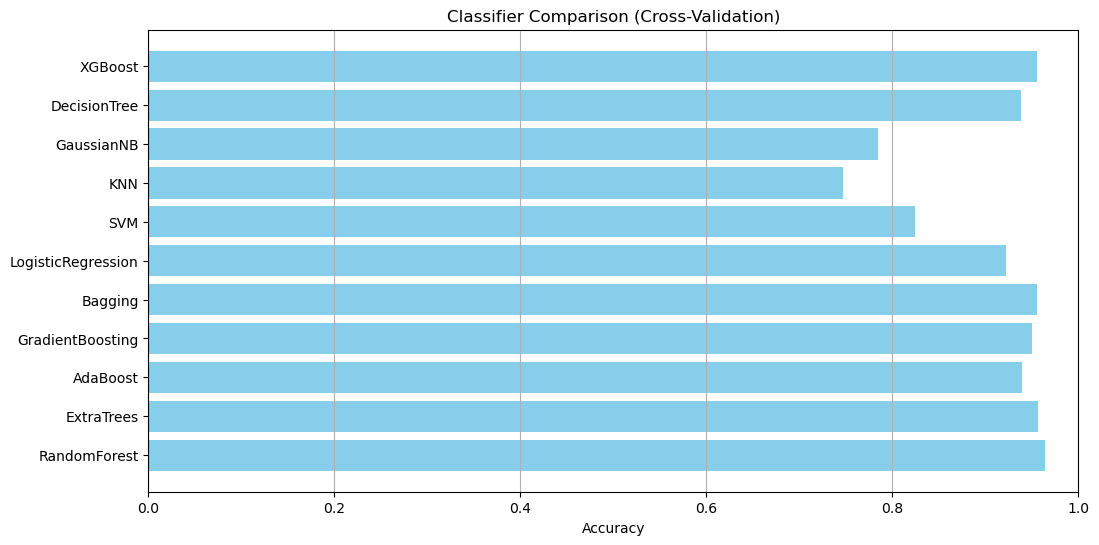

In [46]:
# Compare multiple classifiers using cross-validation
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, BaggingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

classifiers = {
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Bagging': BaggingClassifier(n_estimators=10, random_state=42),
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'GaussianNB': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

summary = []
for name, clf in classifiers.items():
    print(f"\nEvaluating {name}...")
    scores = cross_validate(clf, features, labels, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    summary.append({
        'Classifier': name,
        'Accuracy': scores['test_accuracy'].mean(),
        'Precision': scores['test_precision_macro'].mean(),
        'Recall': scores['test_recall_macro'].mean(),
        'F1': scores['test_f1_macro'].mean()
    })

results_df = pd.DataFrame(summary)
print("\nClassifier Comparison (Cross-Validation):")
#print(results_df.sort_values(by='Accuracy', ascending=False))
print(results_df)

# Plotting the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.barh(results_df['Classifier'], results_df['Accuracy'], color='skyblue')
plt.xlabel('Accuracy')
plt.title('Classifier Comparison (Cross-Validation)')
plt.xlim(0, 1)
plt.grid(axis='x')
plt.show()

In [ ]:
np.save('final_Features/combined_all_features_array.npy', features)
